In [11]:
# Import required libraries
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import tifffile
from pathlib import Path
from ipywidgets import interact, IntSlider, FloatSlider, Dropdown
from joblib import Parallel, delayed
from tqdm.auto import tqdm
import pandas as pd
from scipy import stats

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

print("Libraries loaded successfully!")

Libraries loaded successfully!


## 1. Configuration and File Loading

In [26]:
# Configuration
DATA_DIR = "/Users/lfbarba/GitHub/sdate/data/ct_files/file_3_extracted/"
N_JOBS = -1  # Use all available cores (-1), or specify number of cores

# Find all TIFF files in the directory
tiff_files = sorted(glob.glob(os.path.join(DATA_DIR, "*.tif*")))

print(f"Found {len(tiff_files)} TIFF files")
if tiff_files:
    print(f"First file: {os.path.basename(tiff_files[0])}")
    print(f"Last file: {os.path.basename(tiff_files[-1])}")
else:
    print("No TIFF files found! Please check the directory path.")

Found 751 TIFF files
First file: MI04_020001.tif
Last file: MI04_020751.tif


## 2. Parallel Dynamic Range Analysis

Efficiently compute statistics for each frame using parallel processing.

In [27]:
def analyze_single_frame(filepath):
    """
    Analyze a single TIFF file and return comprehensive statistics.
    
    Returns:
        dict: Statistics including min, max, mean, std, percentiles, etc.
    """
    try:
        img = tifffile.imread(filepath)
        
        stats_dict = {
            'filename': os.path.basename(filepath),
            'min': np.min(img),
            'max': np.max(img),
            'mean': np.mean(img),
            'std': np.std(img),
            'median': np.median(img),
            'p01': np.percentile(img, 1),
            'p05': np.percentile(img, 5),
            'p95': np.percentile(img, 95),
            'p99': np.percentile(img, 99),
            'dtype': str(img.dtype),
            'shape': img.shape,
            'size_mb': img.nbytes / (1024**2)
        }
        
        # Calculate dynamic range metrics
        stats_dict['range'] = stats_dict['max'] - stats_dict['min']
        stats_dict['dynamic_range_db'] = 20 * np.log10(stats_dict['max'] / (stats_dict['min'] + 1e-10))
        
        # Calculate bit depth utilization
        if 'uint16' in stats_dict['dtype']:
            max_possible = 65535
        elif 'uint8' in stats_dict['dtype']:
            max_possible = 255
        else:
            max_possible = stats_dict['max']
        
        stats_dict['bit_utilization'] = (stats_dict['max'] / max_possible) * 100
        
        return stats_dict
    except Exception as e:
        print(f"Error processing {filepath}: {e}")
        return None

# Perform parallel analysis
print(f"Analyzing {len(tiff_files)} frames using {N_JOBS} cores...")
results = Parallel(n_jobs=N_JOBS)(
    delayed(analyze_single_frame)(f) for f in tqdm(tiff_files, desc="Analyzing frames")
)

# Filter out None results and create DataFrame
results = [r for r in results if r is not None]
df_stats = pd.DataFrame(results)
df_stats['frame_number'] = df_stats.index

print(f"\nAnalysis complete! Processed {len(df_stats)} frames successfully.")
print(f"\nDataset Overview:")
print(df_stats[['min', 'max', 'mean', 'std', 'range']].describe())

Analyzing 751 frames using -1 cores...


Analyzing frames:   0%|          | 0/751 [00:00<?, ?it/s]


Analysis complete! Processed 751 frames successfully.

Dataset Overview:
              min          max         mean         std        range
count  751.000000   751.000000   751.000000  751.000000   751.000000
mean   399.988016  2215.960053  1124.084407  274.973962  1815.972037
std    202.907430   618.598186   306.692086   71.706911   615.227689
min      0.000000    88.000000    14.642293    7.289497    88.000000
25%    312.000000  2018.000000  1121.666590  286.052325  1307.000000
50%    319.000000  2349.000000  1122.296137  296.217692  2035.000000
75%    696.000000  2580.500000  1383.340582  297.715607  2269.000000
max    728.000000  2928.000000  1403.155993  302.647414  2618.000000


## 3. Min/Max Values Over Time

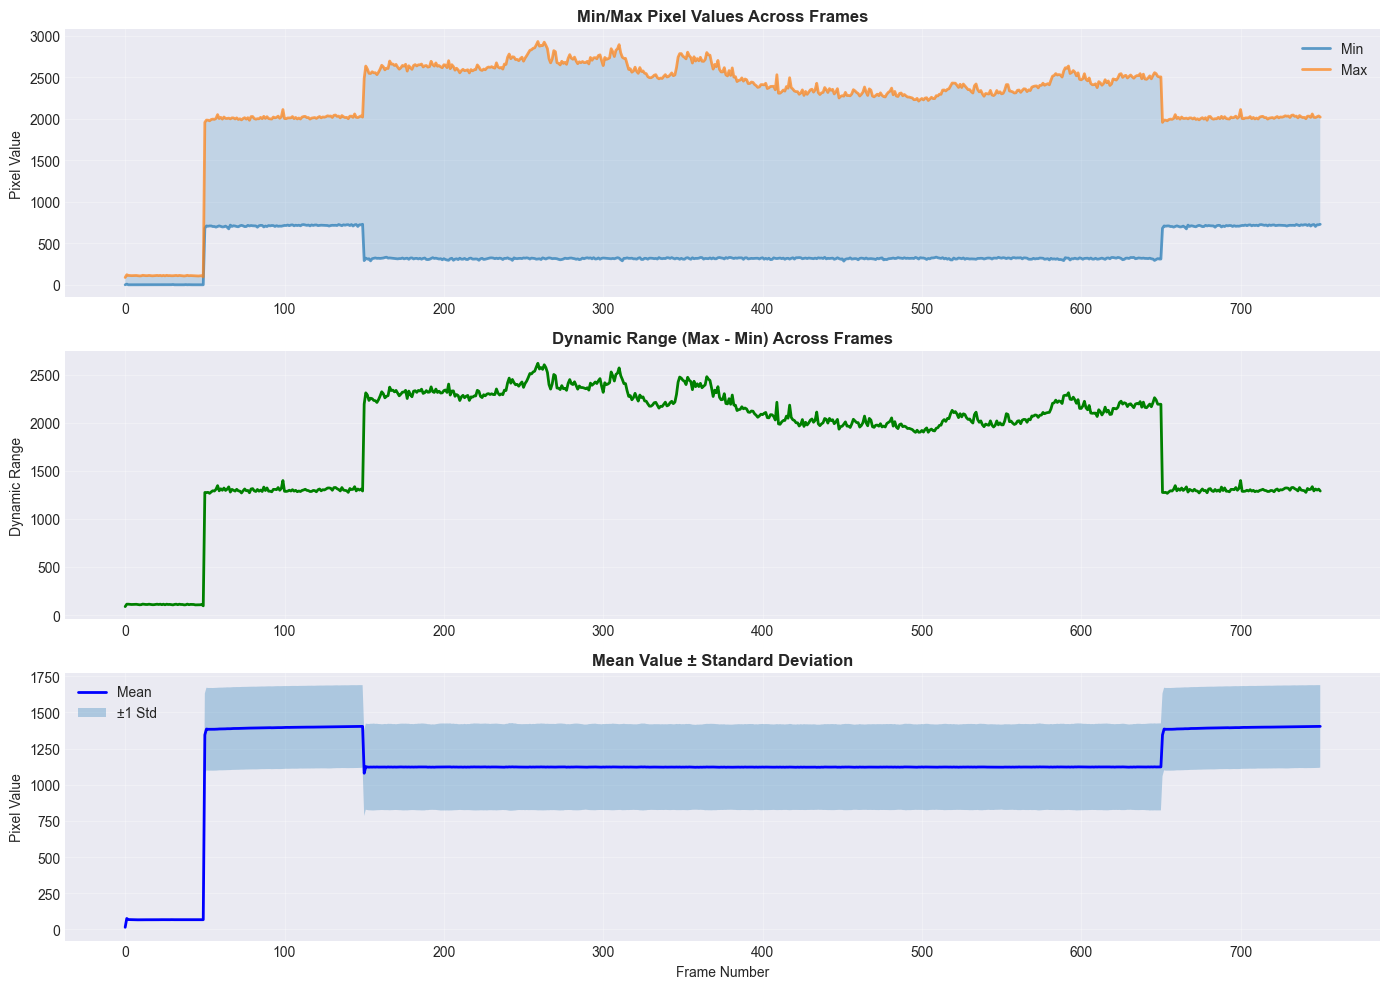

In [28]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Plot 1: Min and Max values
axes[0].plot(df_stats['frame_number'], df_stats['min'], label='Min', alpha=0.7, linewidth=2)
axes[0].plot(df_stats['frame_number'], df_stats['max'], label='Max', alpha=0.7, linewidth=2)
axes[0].fill_between(df_stats['frame_number'], df_stats['min'], df_stats['max'], alpha=0.2)
axes[0].set_ylabel('Pixel Value')
axes[0].set_title('Min/Max Pixel Values Across Frames', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Dynamic range (max - min)
axes[1].plot(df_stats['frame_number'], df_stats['range'], color='green', linewidth=2)
axes[1].set_ylabel('Dynamic Range')
axes[1].set_title('Dynamic Range (Max - Min) Across Frames', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Plot 3: Mean ± Std
axes[2].plot(df_stats['frame_number'], df_stats['mean'], label='Mean', color='blue', linewidth=2)
axes[2].fill_between(df_stats['frame_number'], 
                      df_stats['mean'] - df_stats['std'], 
                      df_stats['mean'] + df_stats['std'], 
                      alpha=0.3, label='±1 Std')
axes[2].set_xlabel('Frame Number')
axes[2].set_ylabel('Pixel Value')
axes[2].set_title('Mean Value ± Standard Deviation', fontsize=12, fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Interactive Histogram Viewer

Use the slider to explore histograms of different frames.

In [29]:
# Cache for loaded images to avoid reloading
image_cache = {}

def load_frame(frame_idx):
    """Load a frame with caching."""
    if frame_idx not in image_cache:
        image_cache[frame_idx] = tifffile.imread(tiff_files[frame_idx])
    return image_cache[frame_idx]

@interact(frame_idx=IntSlider(min=0, max=len(tiff_files)-1, step=1, value=0, description='Frame:'),
          bins=IntSlider(min=50, max=500, step=50, value=200, description='Bins:'),
          log_scale=Dropdown(options=[False, True], value=False, description='Log Scale:'))
def show_histogram(frame_idx, bins, log_scale):
    """Display interactive histogram for selected frame."""
    img = load_frame(frame_idx)
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # Display the image
    im = axes[0].imshow(img, cmap='gray')
    axes[0].set_title(f'Frame {frame_idx}: {os.path.basename(tiff_files[frame_idx])}', fontweight='bold')
    axes[0].axis('off')
    plt.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)
    
    # Display the histogram
    axes[1].hist(img.flatten(), bins=bins, alpha=0.7, color='blue', edgecolor='black')
    axes[1].set_xlabel('Pixel Value')
    axes[1].set_ylabel('Frequency (log scale)' if log_scale else 'Frequency')
    axes[1].set_title(f'Histogram (Min: {df_stats.iloc[frame_idx]["min"]:.0f}, '
                     f'Max: {df_stats.iloc[frame_idx]["max"]:.0f}, '
                     f'Mean: {df_stats.iloc[frame_idx]["mean"]:.1f})', fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    
    if log_scale:
        axes[1].set_yscale('log')
    
    # Add vertical lines for statistics
    axes[1].axvline(df_stats.iloc[frame_idx]['mean'], color='red', linestyle='--', 
                   linewidth=2, label='Mean')
    axes[1].axvline(df_stats.iloc[frame_idx]['median'], color='green', linestyle='--', 
                   linewidth=2, label='Median')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print(f"\nFrame {frame_idx} Statistics:")
    print(f"  Shape: {img.shape}")
    print(f"  Data type: {img.dtype}")
    print(f"  Min: {df_stats.iloc[frame_idx]['min']:.2f}")
    print(f"  Max: {df_stats.iloc[frame_idx]['max']:.2f}")
    print(f"  Mean: {df_stats.iloc[frame_idx]['mean']:.2f}")
    print(f"  Std: {df_stats.iloc[frame_idx]['std']:.2f}")
    print(f"  Median: {df_stats.iloc[frame_idx]['median']:.2f}")
    print(f"  Dynamic Range (dB): {df_stats.iloc[frame_idx]['dynamic_range_db']:.2f}")
    print(f"  Bit Utilization: {df_stats.iloc[frame_idx]['bit_utilization']:.2f}%")

interactive(children=(IntSlider(value=0, description='Frame:', max=750), IntSlider(value=200, description='Bin…

## 5. Percentile Analysis

Visualize how different percentiles evolve over time.

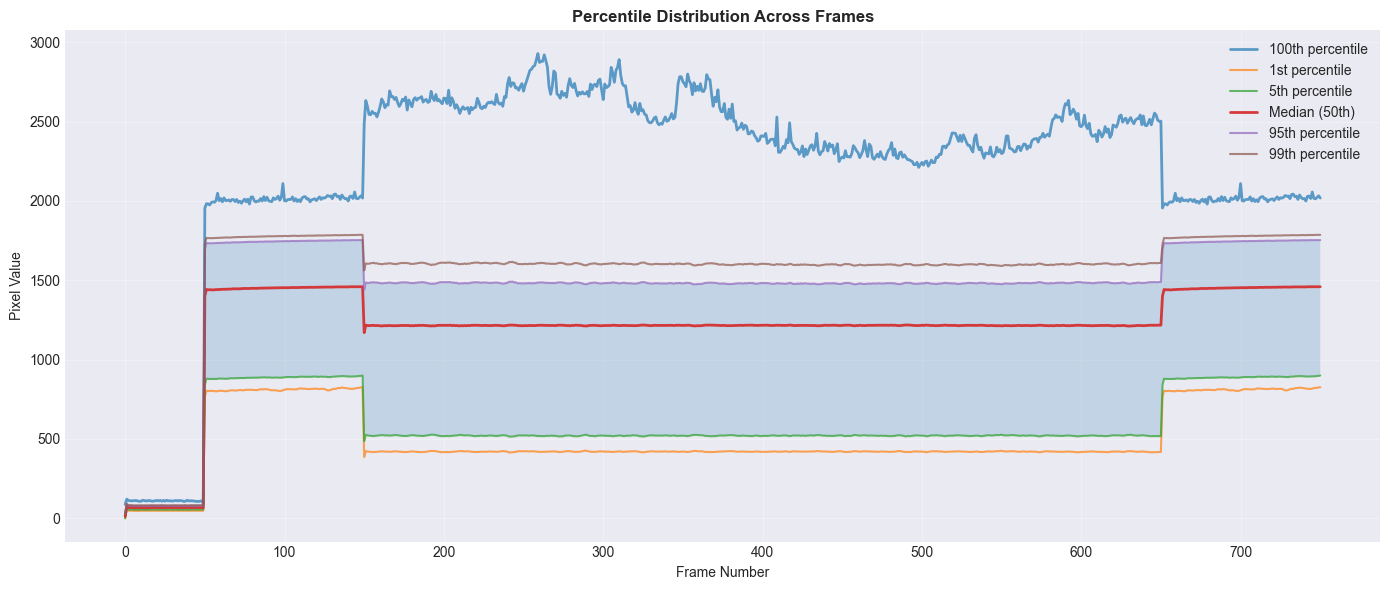

In [30]:
fig, ax = plt.subplots(figsize=(14, 6))

# Plot percentiles
ax.plot(df_stats['frame_number'], df_stats['max'], label='100th percentile', alpha=0.7, linewidth=2)
ax.plot(df_stats['frame_number'], df_stats['p01'], label='1st percentile', alpha=0.7)
ax.plot(df_stats['frame_number'], df_stats['p05'], label='5th percentile', alpha=0.7)
ax.plot(df_stats['frame_number'], df_stats['median'], label='Median (50th)', alpha=0.9, linewidth=2)
ax.plot(df_stats['frame_number'], df_stats['p95'], label='95th percentile', alpha=0.7)
ax.plot(df_stats['frame_number'], df_stats['p99'], label='99th percentile', alpha=0.7)


# Fill between percentiles
ax.fill_between(df_stats['frame_number'], df_stats['p05'], df_stats['p95'], alpha=0.2)

ax.set_xlabel('Frame Number')
ax.set_ylabel('Pixel Value')
ax.set_title('Percentile Distribution Across Frames', fontsize=12, fontweight='bold')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Bit Depth Utilization Analysis

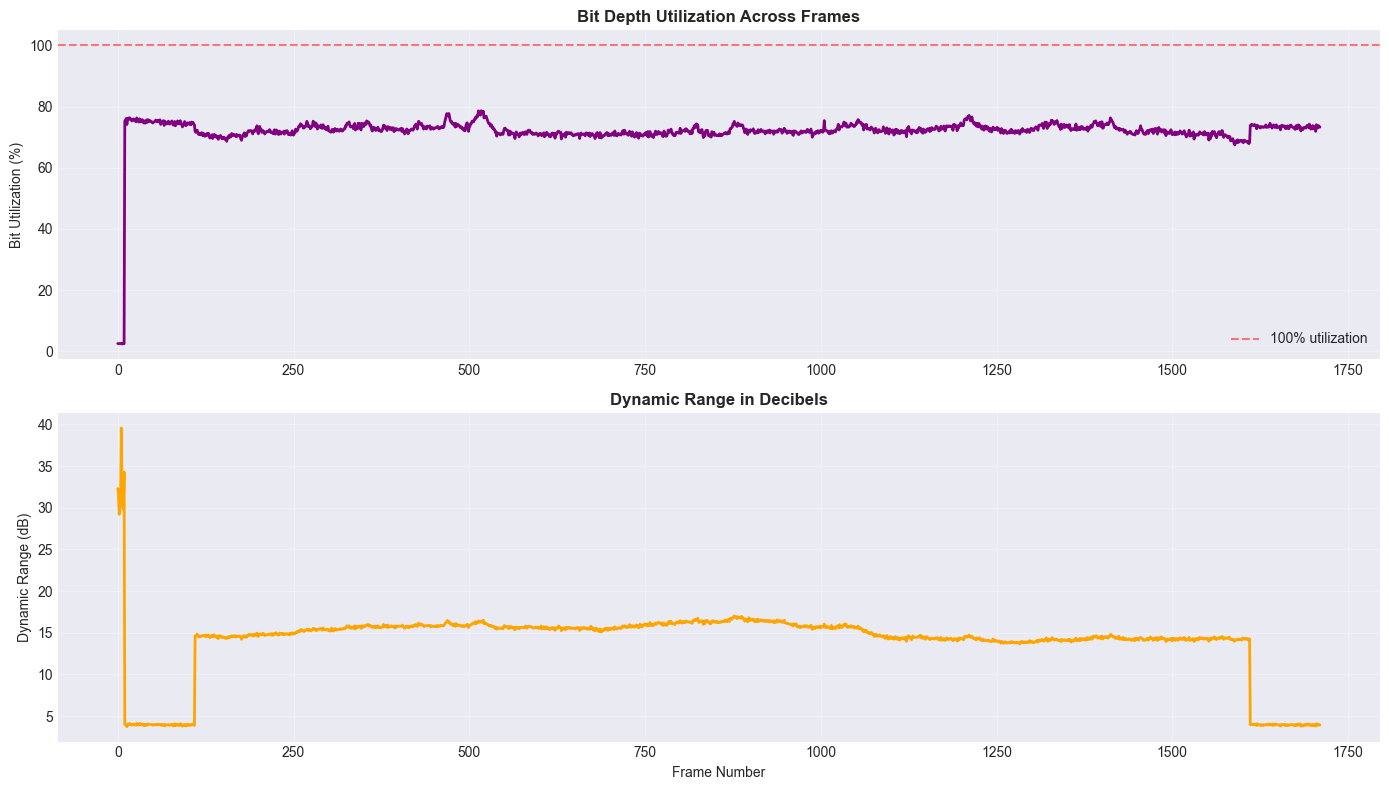


Bit Utilization Statistics:
  Mean: 72.04%
  Min: 2.42%
  Max: 78.62%

Dynamic Range Statistics (dB):
  Mean: 13.95 dB
  Min: 3.73 dB
  Max: 39.57 dB


In [7]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Plot 1: Bit utilization over time
axes[0].plot(df_stats['frame_number'], df_stats['bit_utilization'], linewidth=2, color='purple')
axes[0].axhline(y=100, color='red', linestyle='--', label='100% utilization', alpha=0.5)
axes[0].set_ylabel('Bit Utilization (%)')
axes[0].set_title('Bit Depth Utilization Across Frames', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Dynamic range in dB
axes[1].plot(df_stats['frame_number'], df_stats['dynamic_range_db'], linewidth=2, color='orange')
axes[1].set_xlabel('Frame Number')
axes[1].set_ylabel('Dynamic Range (dB)')
axes[1].set_title('Dynamic Range in Decibels', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nBit Utilization Statistics:")
print(f"  Mean: {df_stats['bit_utilization'].mean():.2f}%")
print(f"  Min: {df_stats['bit_utilization'].min():.2f}%")
print(f"  Max: {df_stats['bit_utilization'].max():.2f}%")
print(f"\nDynamic Range Statistics (dB):")
print(f"  Mean: {df_stats['dynamic_range_db'].mean():.2f} dB")
print(f"  Min: {df_stats['dynamic_range_db'].min():.2f} dB")
print(f"  Max: {df_stats['dynamic_range_db'].max():.2f} dB")

## 7. Temporal Variation Analysis

Analyze how much the frames change over time.

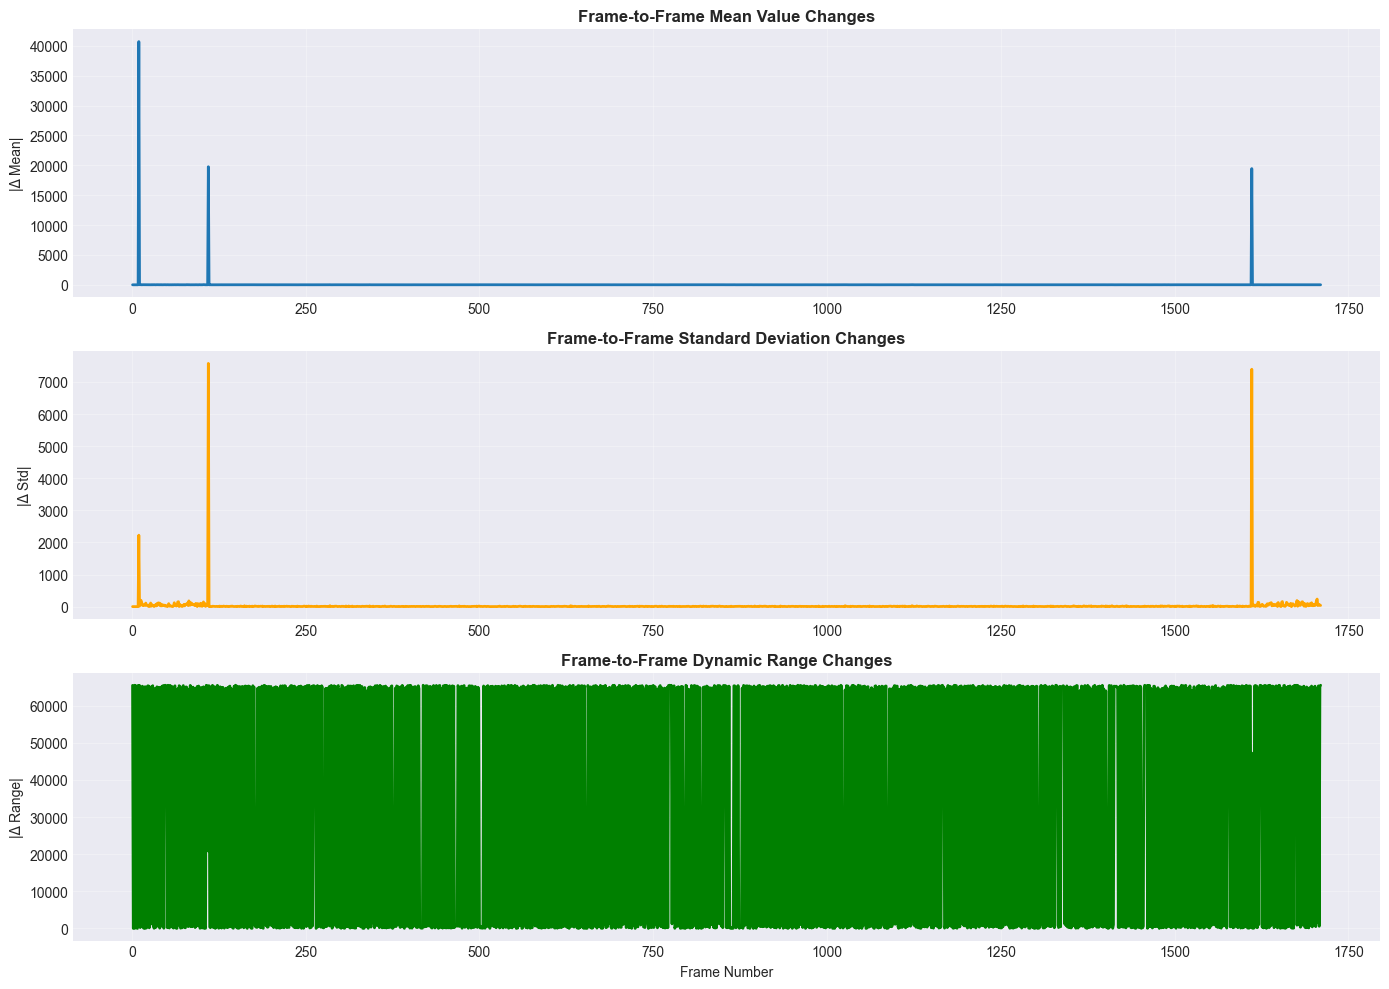


Frames with Largest Changes:

Top 5 frames with largest mean changes:
      frame_number     mean_diff          mean
10              10  40693.196968  40787.854555
110            110  19752.622012  20268.991864
1611          1611  19443.867033  39616.691461
13              13     40.377343  40727.493576
20              20     29.065751  40626.553662

Top 5 frames with largest range changes:
      frame_number  range_diff  range
149            149     65534.0  36902
1045          1045     65533.0  40542
1637          1637     65533.0  17735
1710          1710     65532.0  17486
4                4     65531.0   1613


In [8]:
# Calculate frame-to-frame differences
df_stats['mean_diff'] = df_stats['mean'].diff().abs()
df_stats['std_diff'] = df_stats['std'].diff().abs()
df_stats['range_diff'] = df_stats['range'].diff().abs()

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Plot 1: Mean value changes
axes[0].plot(df_stats['frame_number'][1:], df_stats['mean_diff'][1:], linewidth=2)
axes[0].set_ylabel('|Δ Mean|')
axes[0].set_title('Frame-to-Frame Mean Value Changes', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Plot 2: Std changes
axes[1].plot(df_stats['frame_number'][1:], df_stats['std_diff'][1:], 
            linewidth=2, color='orange')
axes[1].set_ylabel('|Δ Std|')
axes[1].set_title('Frame-to-Frame Standard Deviation Changes', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Plot 3: Range changes
axes[2].plot(df_stats['frame_number'][1:], df_stats['range_diff'][1:], 
            linewidth=2, color='green')
axes[2].set_xlabel('Frame Number')
axes[2].set_ylabel('|Δ Range|')
axes[2].set_title('Frame-to-Frame Dynamic Range Changes', fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Identify frames with largest changes
print("\nFrames with Largest Changes:")
print("\nTop 5 frames with largest mean changes:")
print(df_stats.nlargest(5, 'mean_diff')[['frame_number', 'mean_diff', 'mean']])
print("\nTop 5 frames with largest range changes:")
print(df_stats.nlargest(5, 'range_diff')[['frame_number', 'range_diff', 'range']])

## 8. Correlation Heatmap

Explore correlations between different statistics.

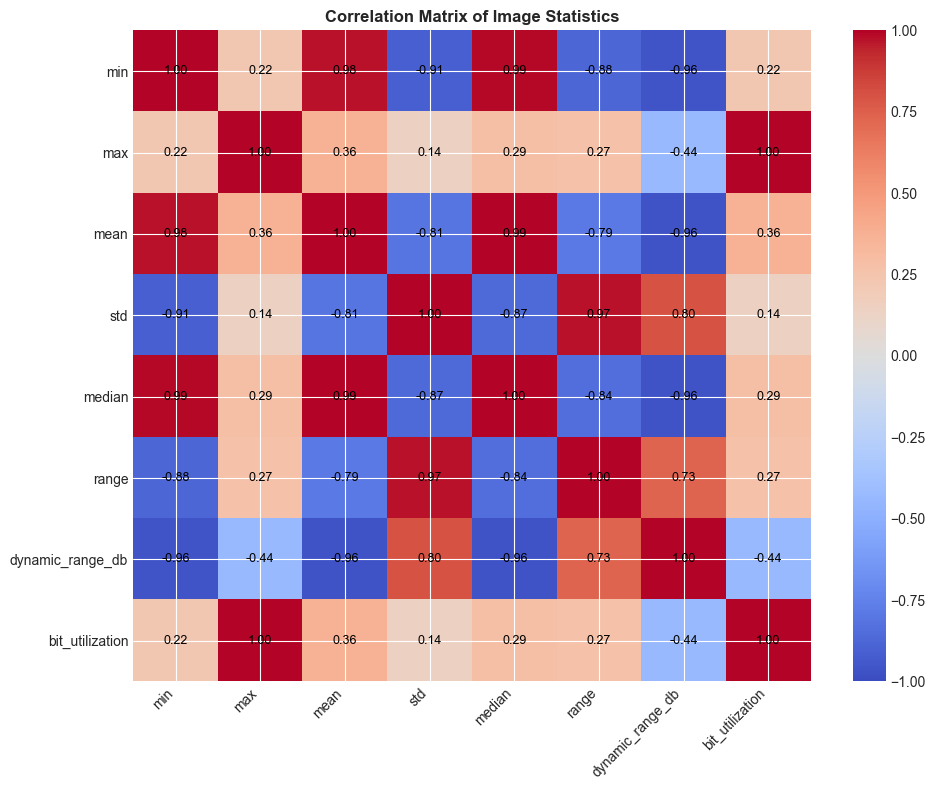

In [9]:
# Select numerical columns for correlation
corr_cols = ['min', 'max', 'mean', 'std', 'median', 'range', 'dynamic_range_db', 'bit_utilization']
corr_matrix = df_stats[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_matrix, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)

# Set ticks and labels
ax.set_xticks(np.arange(len(corr_cols)))
ax.set_yticks(np.arange(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha='right')
ax.set_yticklabels(corr_cols)

# Add correlation values
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        text = ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                      ha='center', va='center', color='black', fontsize=9)

ax.set_title('Correlation Matrix of Image Statistics', fontsize=12, fontweight='bold')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## 9. Summary Statistics and Export

In [10]:
# Display comprehensive summary
print("="*80)
print("COMPREHENSIVE SUMMARY STATISTICS")
print("="*80)
print(f"\nDataset: {DATA_DIR}")
print(f"Total Frames Analyzed: {len(df_stats)}")
print(f"\nImage Properties:")
print(f"  Data Type: {df_stats['dtype'].iloc[0]}")
print(f"  Shape: {df_stats['shape'].iloc[0]}")
print(f"  Average Size: {df_stats['size_mb'].mean():.2f} MB per frame")
print(f"  Total Size: {df_stats['size_mb'].sum():.2f} MB")

print(f"\n{'Statistic':<20} {'Min':<12} {'Max':<12} {'Mean':<12} {'Std':<12}")
print("-"*80)
for col in ['min', 'max', 'mean', 'std', 'median', 'range', 'dynamic_range_db', 'bit_utilization']:
    print(f"{col:<20} {df_stats[col].min():<12.2f} {df_stats[col].max():<12.2f} "
          f"{df_stats[col].mean():<12.2f} {df_stats[col].std():<12.2f}")

# Save statistics to CSV
output_dir = Path(DATA_DIR).parent.parent / 'notebooks' / 'analysis_results'
output_dir.mkdir(exist_ok=True)
output_file = output_dir / f'dynamic_range_stats_{Path(DATA_DIR).stem}.csv'
df_stats.to_csv(output_file, index=False)
print(f"\nStatistics saved to: {output_file}")

COMPREHENSIVE SUMMARY STATISTICS

Dataset: /Users/lfbarba/GitHub/sdate/data/ct_files/file_1_extracted/
Total Frames Analyzed: 1711

Image Properties:
  Data Type: uint16
  Shape: (2160, 2560)
  Average Size: 10.55 MB per frame
  Total Size: 18045.70 MB

Statistic            Min          Max          Mean         Std         
--------------------------------------------------------------------------------
min                  18.00        31614.00     10883.76     7324.97     
max                  1587.00      51523.00     47214.13     3648.76     
mean                 94.62        40787.85     22592.03     6500.32     
std                  4.42         11329.29     9268.55      2761.26     
median               95.00        40708.00     18722.48     7764.13     
range                1551.00      43739.00     36330.37     7416.13     
dynamic_range_db     3.73         39.57        13.95        3.95        
bit_utilization      2.42         78.62        72.04        5.57        


FileNotFoundError: [Errno 2] No such file or directory: '/Users/lfbarba/GitHub/sdate/data/notebooks/analysis_results'

## 10. Advanced: 2D Histogram (Value vs. Time)

Visualize how pixel value distributions change over time.

In [ ]:
# Create 2D histogram showing value distribution evolution
@interact(sample_frames=IntSlider(min=10, max=min(100, len(tiff_files)), 
                                  step=10, value=50, description='Sample Size:'),
          value_bins=IntSlider(min=50, max=200, step=50, value=100, description='Value Bins:'))
def show_2d_histogram(sample_frames, value_bins):
    """Display 2D histogram of pixel values over time."""
    # Sample frames evenly
    frame_indices = np.linspace(0, len(tiff_files)-1, sample_frames, dtype=int)
    
    # Determine value range
    global_min = df_stats['min'].min()
    global_max = df_stats['max'].max()
    
    # Create bins
    value_edges = np.linspace(global_min, global_max, value_bins)
    hist_2d = np.zeros((value_bins-1, sample_frames))
    
    # Compute histograms for sampled frames
    print(f"Computing 2D histogram for {sample_frames} frames...")
    for i, idx in enumerate(tqdm(frame_indices, desc="Processing")):
        img = load_frame(idx)
        hist, _ = np.histogram(img.flatten(), bins=value_edges)
        hist_2d[:, i] = hist
    
    # Plot
    fig, ax = plt.subplots(figsize=(14, 8))
    im = ax.imshow(hist_2d, aspect='auto', cmap='viridis', 
                   extent=[0, sample_frames-1, global_min, global_max],
                   origin='lower', interpolation='bilinear')
    
    ax.set_xlabel('Frame Index (sampled)', fontsize=12)
    ax.set_ylabel('Pixel Value', fontsize=12)
    ax.set_title('2D Histogram: Pixel Value Distribution Evolution', 
                fontsize=12, fontweight='bold')
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Frequency (log scale)', fontsize=10)
    
    # Use log scale for colormap
    im.set_norm(plt.cm.colors.LogNorm(vmin=hist_2d[hist_2d>0].min(), 
                                       vmax=hist_2d.max()))
    
    plt.tight_layout()
    plt.show()

interactive(children=(IntSlider(value=50, description='Sample Size:', min=10, step=10), IntSlider(value=100, d…

Image shape: (300, 2016)
Image dtype: uint16
Image min: 0, max: 389


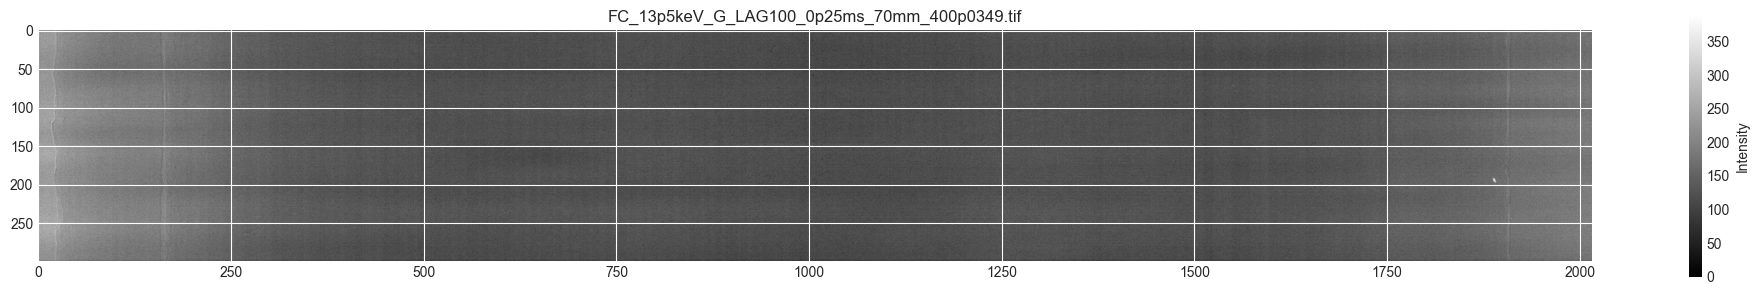

In [ ]:
# Load and display a TIFF image
from tifffile import imread
import matplotlib.pyplot as plt

image_path = f'{DATA_DIR}/FC_13p5keV_G_LAG100_0p25ms_70mm_400p0349.tif'
img = imread(image_path)

print(f"Image shape: {img.shape}")
print(f"Image dtype: {img.dtype}")
print(f"Image min: {img.min()}, max: {img.max()}")

plt.figure(figsize=(20, 3))
plt.imshow(img, cmap='gray')
plt.colorbar(label='Intensity')
plt.title('FC_13p5keV_G_LAG100_0p25ms_70mm_400p0349.tif')
plt.tight_layout()
plt.show()